# Dependencies

In [1]:
import datetime
import yaml
import numpy as np
import pandas as pd
import pathlib
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import matplotlib.pyplot as plt

from src.data.prepare_data import prepare_non_rnn_data, prepare_rnn_data, concatenate_multi_input_data
from src.train.models import build_dmq_v0, build_dmq
from src.train.losses import make_total_tilted_loss, tilted_loss, make_tilted_loss
from src.utils.evaluation import compute_oos_r1_score, compute_oos_r2_score

keras.utils.set_random_seed(1)
# =====================================================================
# Configuration
# =====================================================================
# Load config for defaults
with open("config/config_file.yaml", "r") as f:
    config = yaml.safe_load(f)

BASE_PATH = pathlib.Path('.')
data_config = config['data']
INPUT_FILES = data_config['input_files']
TARGET_FILE = data_config['target_file']
TARGETS_PATH = BASE_PATH/ 'data' / 'processed' / TARGET_FILE
INPUT_PATHS = [BASE_PATH / 'data' / 'processed' / file for file in INPUT_FILES]
START_DATE = data_config['start_date']

# Data configurations
TARGET_IDX = 0  # 0: Infl_yoy, 1: IP_yoy, 2: Unrate_yoy
TIME_STEPS = 12  # Number of quarters for RNN
YEAR = 1997     # Train cutoff year
VAL_MONTHS = 60   # Number of validation years
TEST_MONTHS = 240

QUANTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
EPOCHS = 500
BATCH_SIZE = 4
LEARNING_RATE = 0.001

target_name_dict = {
    0: 'Infl_yoy',
    1: 'IP_yoy',
    2: 'Unrate_yoy',
}

target_name = target_name_dict[TARGET_IDX]
print(f"Experimental framework for target: {target_name}")

Experimental framework for target: Infl_yoy


# Helper functions

In [2]:
def plot_and_evaluate_train_predictions(
        y_pred, 
        y_true,
        multi_quantile=False
):
    
    plt.plot(y_true, label='Actual values')
    if multi_quantile:
        for i in range(y_pred.shape[1]):
            plt.plot(y_pred[:,i], label=f'Predicted Q{i+1} values')
    else:
        plt.plot(y_pred, label='Predicted')
    plt.legend()
    plt.show()


def evaluate_quantile_predictions(
        y_pred,
        y_true,
        q_benchmarks,
        mean_benchmark
):
    r1_all = []
    for i,q in enumerate(QUANTILES):

        r1_q = compute_oos_r1_score(
            benchmark_pred=q_benchmarks[:,i],
            y_true=y_true.flatten(),
            y_pred=y_pred[:,i],
            q=q
        )
        r1_all.append(r1_q)
        print(f'R1 for q{q}: {r1_q}')

    print(f'Mean R1: {np.mean(r1_all)}')

    mean_preds = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)

    r2 = compute_oos_r2_score(
        y_true=y_true.flatten(),
        y_pred=mean_preds.flatten(),
        benchmark=mean_benchmark
    )

    print(f'R2 score: {r2}')



# Static data

In [3]:
non_rnn_data = prepare_non_rnn_data(
    targets_path=TARGETS_PATH,
    input_paths=INPUT_PATHS,
    start_date=START_DATE,
    train_cutoff_year=YEAR,
    val_months=VAL_MONTHS,
    test_months=TEST_MONTHS,
)

(
    X_train,
    X_val,
    X_test,
    targets_train,
    targets_val,
    targets_test
) = non_rnn_data

print(targets_train.shape, targets_val.shape, targets_test.shape)

targets_train = targets_train.copy()
targets_val   = targets_val.copy()
targets_test  = targets_test.copy()

X_train_full = pd.concat([X_train, X_val])
targets_train_full = pd.concat([targets_train, targets_val])
y_train = targets_train[target_name]
y_train_full = targets_train_full[target_name]
y_val = targets_val[target_name]
y_test = targets_test[target_name]
mq_y_train_full = np.repeat(y_train_full.values.reshape(-1,1), 5, axis=1)
mq_y_val = np.repeat(y_val.values.reshape(-1,1), 5, axis=1)

(384, 3) (60, 3) (240, 3)


In [11]:
y_train

date
1961-01-01    1.587603
1961-02-01    1.451502
1961-03-01    1.451502
1961-04-01    0.909863
1961-05-01    0.908944
                ...   
1992-08-01    3.028350
1992-09-01    2.948793
1992-10-01    3.227243
1992-11-01    3.072768
1992-12-01    2.923559
Name: Infl_yoy, Length: 384, dtype: float64

# Baselines

## Benchmarks

In [4]:
benchmark_dict = {
    0: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_Infl_yoy.csv',
    1: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_IP_yoy.csv',
    2: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_Unrate_yoy.csv'
}

benchmarks = pd.read_csv(benchmark_dict[TARGET_IDX], index_col=0, parse_dates=True)
benchmarks.head()

,Naive_Q5,Naive_Q25,Naive_Q50,Naive_Q75,Naive_Q95,Naive_Mean,IAR_Q5,IAR_Q25,IAR_Q50,IAR_Q75,IAR_Q95
1998-01-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.361970,3.756464,5.147799,6.256978,7.765424
1998-02-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.484558,3.732758,5.124497,6.587725,7.953568
1998-03-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.680255,3.730914,4.970536,6.832331,8.255991
1998-04-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.763296,3.587599,4.684487,6.892354,8.381262
1998-05-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.674143,3.754978,5.074781,6.986625,8.243524


In [5]:
naive_preds = benchmarks.loc[X_test.index, 'Naive_Q5': 'Naive_Q95']
naive_mean =  benchmarks.loc[X_test.index, 'Naive_Mean']

evaluate_quantile_predictions(
    y_pred=naive_preds.values,
    y_true=y_test.values,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

R1 for q0.05: 0.0
R1 for q0.25: 0.0
R1 for q0.5: 0.0
R1 for q0.75: 0.0
R1 for q0.95: 0.0
Mean R1: 0.0
R2 score: -10.512660684217657


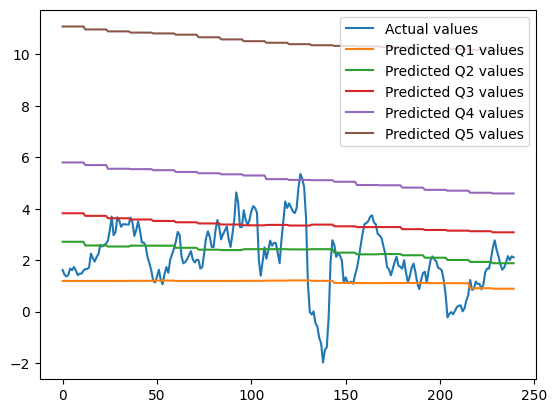

In [6]:
plot_and_evaluate_train_predictions(
    y_pred=naive_preds.values,
    y_true=y_test.values,
    multi_quantile=True
)

In [6]:
benchmarks.columns = benchmarks.columns.str.replace(
    r'VG|IAR|UAR',
    'LIT',
    regex=True
)
lit_preds = benchmarks.loc[X_test.index, 'LIT_Q5': 'LIT_Q95']
evaluate_quantile_predictions(
    y_pred=lit_preds.values,
    y_true=y_test.values,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)


R1 for q0.05: -57.15699758700892
R1 for q0.25: -20.59664011805271
R1 for q0.5: -18.507116249275924
R1 for q0.75: -13.56743084191634
R1 for q0.95: -26.105981692328584
Mean R1: -27.186833297716497
R2 score: 8.813611533399602


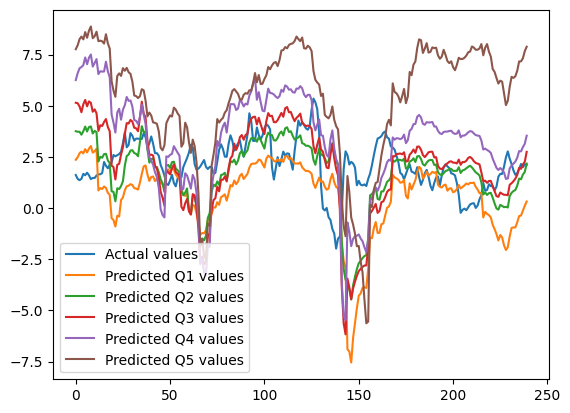

In [8]:
plot_and_evaluate_train_predictions(
    y_pred=lit_preds.values,
    y_true=y_test.values,
    multi_quantile=True
)

## Check training loss at init for a network that predicts the median

In [9]:
quantile = 0.5
subsample_size = X_train_full.shape[0]
learning_rate = 1e-5

for quantile in [0.05, 0.25, 0.5, 0.75, 0.95]:
    model_1 = keras.Sequential(
        [
            keras.layers.Dense(
                32,
                kernel_initializer='zeros',
                bias_initializer='zeros'
            ),
            keras.layers.Dense(
                1, 
                bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile)))
            )
        ]
    )
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate), 
        loss=make_tilted_loss(quantile)
    )

    history = model_1.fit(
        x=X_train_full.values[:subsample_size],
        y=y_train_full.values[:subsample_size],
        epochs=1, 
        batch_size=4,
        validation_data=(X_val, y_val),
        # callbacks=[
        #     keras.callbacks.EarlyStopping(
        #         monitor='val_loss',
        #         min_delta=1e-4,
        #         patience=20,
        #         restore_best_weights=False
        #     )
        # ]
    )

    # Training loss at init should be 
    y_train_full_tf = tf.constant(y_train_full.values)
    y_mean_tf = tf.constant(y_train_full.quantile(quantile))
    expected_loss = tilted_loss(y_train_full_tf, y_mean_tf, q=quantile)

    print(
        (f'Initial loss: {np.round(history.history['loss'][0],4)}. '
        f'Expected: {np.round(expected_loss, 4)}')
    )

# plt.plot(history.history['loss'], label='Training loss')
# plt.plot(history.history['val_loss'], label='Validation loss')
# plt.legend()
# plt.show()

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1798 - val_loss: 0.0748
Initial loss: 0.1798. Expected: 0.1804
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7130 - val_loss: 0.1283
Initial loss: 0.713. Expected: 0.7156
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0627 - val_loss: 0.5413
Initial loss: 1.0627. Expected: 1.0684
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0366 - val_loss: 0.7665
Initial loss: 1.0366. Expected: 1.0418
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3761 - val_loss: 0.4179
Initial loss: 0.3761. Expected: 0.3776


Loss works, we can move on. Note that to check the initial loss the kernel must be initialized as zero.

# RNN data

In [7]:
import json

with open('data/fred_group_dict.json', 'r') as f:
    fred_group_dict = json.load(f)

fred_groups = list(fred_group_dict.values())

In [8]:
rnn_data = prepare_rnn_data(
    targets_path=TARGETS_PATH,
    input_paths=INPUT_PATHS,
    start_date=START_DATE,
    train_cutoff_year=YEAR,
    val_months=VAL_MONTHS,
    test_months=TEST_MONTHS,
    n_timesteps=12,
    split_groups=None
)

(
    X_train_rnn,
    X_val_rnn,
    X_test_rnn,
    targets_train_rnn,
    targets_val_rnn,
    targets_test_rnn
) = rnn_data

if not isinstance(X_train_rnn, list):
    print(X_train_rnn.shape, X_val_rnn.shape, X_test_rnn.shape)
else:
    print([X.shape for X in X_train_rnn])
    print([X.shape for X in X_val_rnn])
    print([X.shape for X in X_test_rnn])

print(targets_train_rnn.shape, targets_val_rnn.shape, targets_test_rnn.shape)

# Create single target vector
y_train_rnn = targets_train_rnn[:,TARGET_IDX]
y_val_rnn = targets_val_rnn[:,TARGET_IDX]
y_test_rnn = targets_test_rnn[:, TARGET_IDX]

mq_y_train_rnn = np.repeat(y_train_rnn.reshape(-1,1), len(QUANTILES), axis=1)
mq_y_val_rnn = np.repeat(y_val_rnn.reshape(-1,1), len(QUANTILES), axis=1)
mq_y_test_rnn = np.repeat(y_test_rnn.reshape(-1,1), len(QUANTILES), axis=1)

# Stack up the sequences to create a full training set
if isinstance(X_train, list):
    X_train_rnn_full = concatenate_multi_input_data(X_train_rnn, X_val_rnn)
else:
    X_train_rnn_full = np.concatenate([X_train_rnn, X_val_rnn])
mq_y_train_rnn_full = np.concatenate([mq_y_train_rnn, mq_y_val_rnn], axis=0)

(373, 12, 123) (60, 12, 123) (240, 12, 123)
(373, 3) (60, 3) (240, 3)


In [12]:
X_train_rnn_full.shape

(433, 12, 123)

# New DMQ

Epoch 1/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 92.4075 - val_loss: 61.5002
Epoch 2/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 43.5259 - val_loss: 28.8654
Epoch 3/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 20.5173 - val_loss: 13.6059
Epoch 4/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.8326 - val_loss: 6.5445
Epoch 5/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.8830 - val_loss: 3.2883
Epoch 6/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.6600 - val_loss: 1.7553
Epoch 7/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.4976 - val_loss: 1.0474
Epoch 8/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0575 - val_loss: 0.7729
Epoch 9/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9685 - val_loss: 0.6469
Epoch 10/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7222 - val_loss: 0.5368
Epoch 11/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6039 - val_loss: 0.4638
Epoch 12/200
109/109 ━━━━━━━━━━━━

<Axes: >

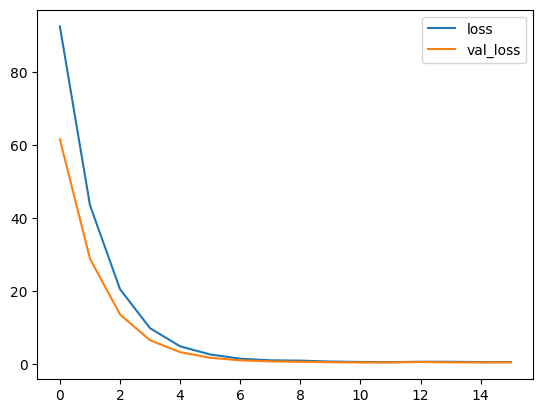

In [30]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

bias_initializers = {
    q: keras.initializers.Constant(y_train.iloc[-12:].quantile(q)) for q in QUANTILES
}

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 2, 
    'n_shared_layers': 2, 
    'n_qtask_layers': 2, 
    'n_recurrent_nodes': 32,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'he_normal',
    'lower_quantiles': None, 
    'upper_quantiles': None, 
    'loss_weights':  None,
    'bias_initializers':  None,
    'space_quantiles': True
}

hps = {
    'lr': 1e-3,
    'l2': 0.1
}

builder_params.update(hps)

model = build_dmq(
    **builder_params
)

# keras.utils.plot_model(model)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_rnn_full,
    mq_y_train_rnn_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


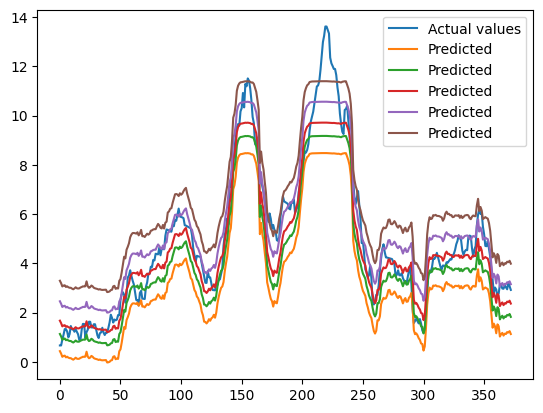

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


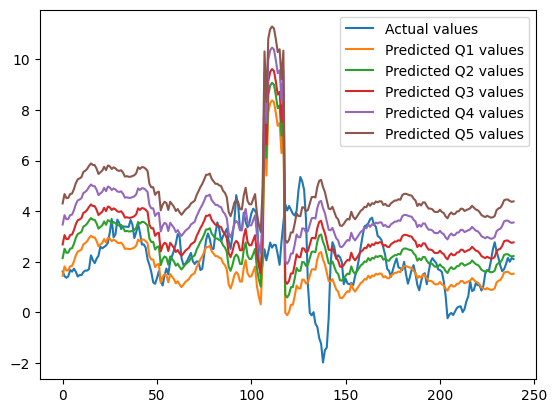

R1 for q0.05: -163.53614927821968
R1 for q0.25: -42.6360788421549
R1 for q0.5: -3.1066474408222744
R1 for q0.75: 27.54925591134829
R1 for q0.95: 58.25559277086484
Mean R1: -24.69480537579675
R2 score: 21.271006058451903


In [31]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

# DMQ

Epoch 1/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.9908 - val_loss: 0.1920
Epoch 2/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3036 - val_loss: 0.0977
Epoch 3/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1965 - val_loss: 0.1066
Epoch 4/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1588 - val_loss: 0.0910
Epoch 5/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1411 - val_loss: 0.0717
Epoch 6/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1197 - val_loss: 0.0961
Epoch 7/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1137 - val_loss: 0.0658
Epoch 8/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1007 - val_loss: 0.0882
Epoch 9/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0986 - val_loss: 0.0517
Epoch 10/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1027 - val_loss: 0.0464
Epoch 11/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1070 - val_loss: 0.0696
Epoch 12/200
109/109 ━━━━━━━━━━━━━━━━━━

<Axes: >

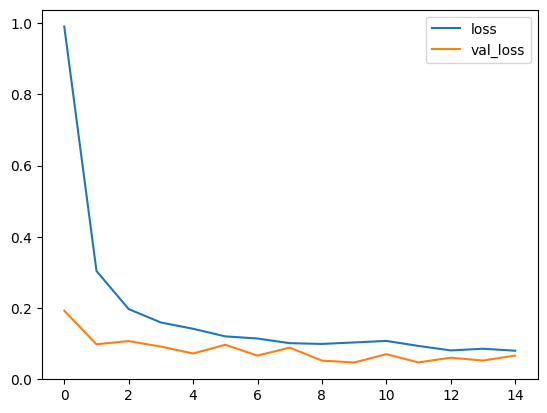

In [ ]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 2, 
    'n_shared_layers': 2, 
    'n_qtask_layers': 2, 
    'n_recurrent_nodes': 32,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'he_normal',
    'lower_quantiles': None, 
    'upper_quantiles': None, 
    'loss_weights':  [1.0]*len(QUANTILES),
    'bias_initializers':  None
}

hps = {
    'l1': 0.0,
    'l2': 0.0,
    'lr': 1e-3
}

builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5
)

history = model.fit(
    X_train_rnn_full,
    mq_y_train_rnn_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


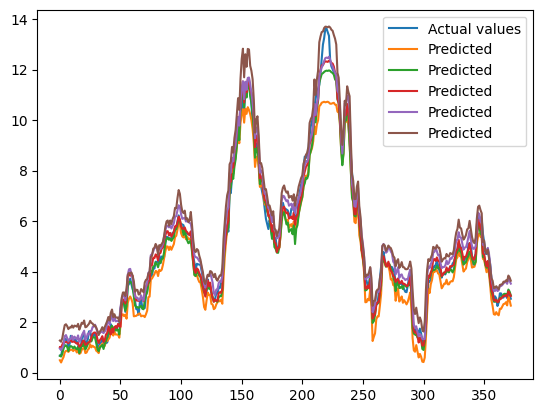

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


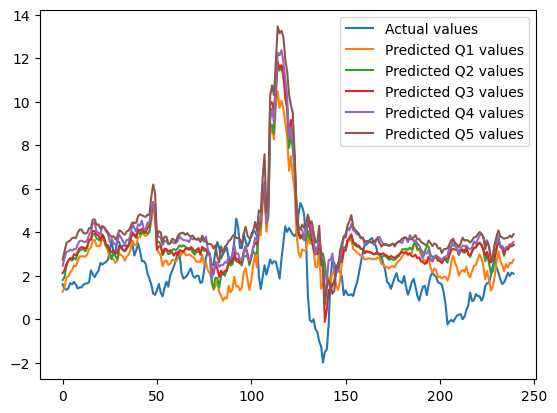

R1 for q0.05: -504.0604702086279
R1 for q0.25: -136.27420274163345
R1 for q0.5: -19.48333888018807
R1 for q0.75: 30.856112146030334
R1 for q0.95: 65.3869646597902
Mean R1: -112.71498700492577
R2 score: -6.13399065441409


In [23]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

## Add l2 penalty

In [14]:
input_shapes

[(12, 123)]

Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 2.7878 - val_loss: 2.4171
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.2625 - val_loss: 2.0102
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8364 - val_loss: 1.6488
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4897 - val_loss: 1.3502
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2114 - val_loss: 1.1087
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9895 - val_loss: 0.9134
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8115 - val_loss: 0.7566
Epoch 8/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6739 - val_loss: 0.6419
Epoch 9/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5646 - val_loss: 0.5426
Epoch 10/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4782 - val_loss: 0.4731
Epoch 11/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4096 - val_loss: 0.4081
Epoch 12/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/ste

<Axes: >

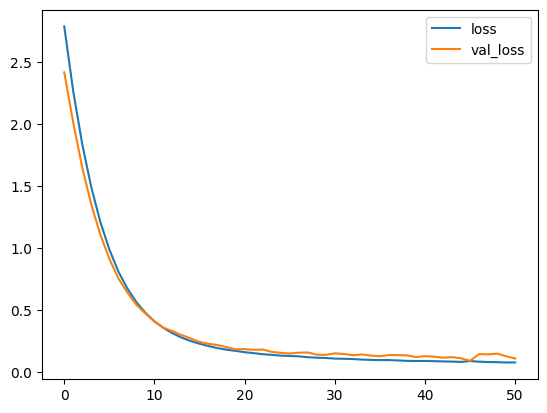

In [42]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

bias_initializers = {
    q: keras.initializers.Constant(y_train.iloc[-12:].quantile(q)) for q in QUANTILES
}

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 2, 
    'n_shared_layers': 2, 
    'n_qtask_layers': 2, 
    'n_recurrent_nodes': 32,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'glorot_uniform',
    'lower_quantiles': [.05, .25], 
    'upper_quantiles': [.75, .95], 
    'loss_weights':  [.28, .17, .11, .17, .28],
    'bias_initializers':  bias_initializers
}

hps = {
    'l1': 0.0,
    'l2': 5e-3,
    'rec_drop': 0.0,
    'lr': 3e-4
}

builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


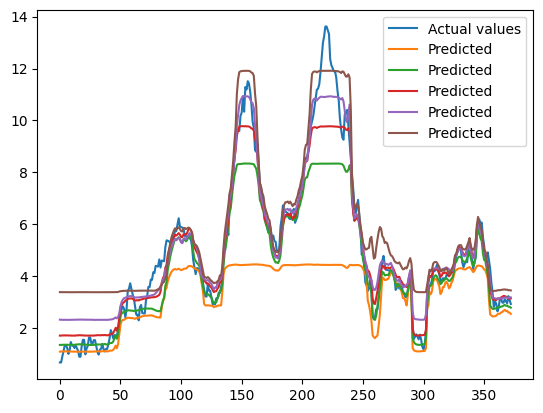

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


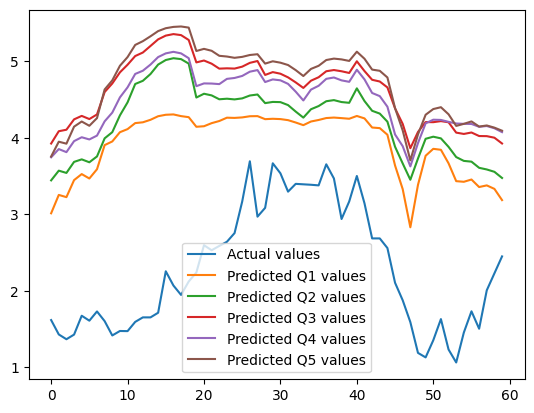

R1 for q0.05: -2602.199261643561
R1 for q0.25: -209.98267797777456
R1 for q0.5: -70.34033843851073
R1 for q0.75: 33.84976608541663
R1 for q0.95: 71.65249568891832
Mean R1: -555.4040032571022
R2 score: 6.818506651480128


In [43]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)